In [1]:
# CELL 1: SETUP & IMPORTS
import os
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Buat folder untuk menyimpan semua hasil agar tidak berantakan
SAVE_DIR = "results_exp2"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")
if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Menggunakan device: cuda
Nama GPU: NVIDIA GeForce RTX 5070


In [2]:
# CELL 2: FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
# CELL 3: DATASET & STRATIFIED K-FOLD (UPDATED LOCAL PATHS)
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold

# 1. Kunci Lokasi Data Lokal
data_dir = r"C:\Users\asfan\Data\ham10000\full"
csv_path = r"C:\Users\asfan\Data\ham10000\HAM10000_metadata.csv"

# 2. Baca Metadata dan Petakan Kelas
df = pd.read_csv(csv_path)
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Mapping kelas teks ('dx') menjadi indeks angka
df['label'] = df['dx'].map(class_to_idx)

# Membangun full path untuk setiap gambar secara otomatis
# Asumsi format gambar adalah .jpg dan nama file sama dengan image_id
df['image_path'] = df.apply(lambda row: os.path.join(data_dir, row['dx'], f"{row['image_id']}.jpg"), axis=1)

# Verifikasi path (Cek apakah gambar pertama benar-benar ada)
print(f"Total data: {len(df)}")
print(f"Contoh path gambar: {df.iloc[0]['image_path']}")
if not os.path.exists(df.iloc[0]['image_path']):
    print("WARNING: Path gambar tidak ditemukan! Pastikan ekstensi .jpg atau nama folder sesuai.")

# 3. Class Dataset Kustom
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 4. Augmentasi Data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Persiapan Stratified 5-Fold
X = df['image_path'].values
y = df['label'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Dataset dan Stratified K-Fold siap!")

Total data: 10015
Contoh path gambar: C:\Users\asfan\Data\ham10000\full\bkl\ISIC_0027419.jpg
Dataset dan Stratified K-Fold siap!


In [4]:
# CELL 4 (REVISI UNTUK EXP 2): ConvNeXt + Spatial Attention
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        y = torch.cat([avg_out, max_out], dim=1)
        y = self.conv(y)
        return x * self.sigmoid(y)

class ConvNeXt_Spatial_Attention(nn.Module):
    def __init__(self, num_classes=7):
        super(ConvNeXt_Spatial_Attention, self).__init__()
        convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        self.features = convnext.features
        
        # Menggunakan Spatial Attention sebagai pengganti SE
        self.spatial_attention = SpatialAttention(kernel_size=7)
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(1),
            nn.LayerNorm(768, eps=1e-6),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.spatial_attention(x) # Inject Spatial Attention di sini
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [5]:
# CELL 5: TRAINING ENGINE WITH METRIC TRACKING
def train_model(fold, model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time = time.time()
    torch.cuda.reset_peak_memory_stats()
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct.double() / total
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
                val_total += labels.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct.double() / val_total
        
        # Simpan metrik
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_acc'].append(epoch_val_acc.item())
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        # Simpan model terbaik (.pth)
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            model_save_path = os.path.join(SAVE_DIR, f"exp2_fold{fold}_best_model.pth")
            torch.save(model.state_dict(), model_save_path)
            
    # Kalkulasi performa hardware
    end_time = time.time()
    training_time = end_time - start_time
    max_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) # Dalam MB
    
    # Simpan history ke JSON
    with open(os.path.join(SAVE_DIR, f"exp2_fold{fold}_history.json"), 'w') as f:
        json.dump(history, f)
        
    return history, training_time, max_memory

In [6]:
# CELL 6: EVALUATION & REPORTING
def evaluate_and_plot(fold, model, val_loader, history, training_time, max_memory, class_names):
    # Load model terbaik
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"exp2_fold{fold}_best_model.pth")))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Classification Report & Metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(SAVE_DIR, f"exp2_fold{fold}_classification_report.csv"))
    
    # Simpan resource metrik
    resource_log = {
        'training_time_seconds': training_time,
        'max_gpu_memory_mb': max_memory,
        'overall_accuracy': accuracy_score(all_labels, all_preds)
    }
    with open(os.path.join(SAVE_DIR, f"exp2_fold{fold}_resources.json"), 'w') as f:
        json.dump(resource_log, f)
        
    # 2. Plot Loss & Accuracy Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss Curve - Fold {fold}')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'Accuracy Curve - Fold {fold}')
    ax2.legend()
    plt.savefig(os.path.join(SAVE_DIR, f"exp2_fold{fold}_learning_curves.png"))
    plt.show()
    
    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(SAVE_DIR, f"exp2_fold{fold}_confusion_matrix.png"))
    plt.show()
    
    print(f"Semua log dan grafik untuk Fold {fold} berhasil disimpan di folder: {SAVE_DIR}")

# CONTOH EKSEKUSI (Bisa diletakkan di dalam loop Stratified K-Fold)
# class_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
# criterion = FocalLoss(gamma=2)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# history, t_time, max_mem = train_model(fold=1, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer)
# evaluate_and_plot(fold=1, model=model, val_loader=val_loader, history=history, training_time=t_time, max_memory=max_mem, class_names=class_names)

Mulai Eksperimen 2: ConvNeXt + Spatial Attention + Focal Loss
Menyimpan di folder: results_exp2

---> Memulai Fold 1 <---
Epoch 1/50 - Train Loss: 0.3969 Acc: 0.7506 | Val Loss: 0.2745 Acc: 0.8043
Epoch 2/50 - Train Loss: 0.2006 Acc: 0.8431 | Val Loss: 0.1782 Acc: 0.8562
Epoch 3/50 - Train Loss: 0.1384 Acc: 0.8794 | Val Loss: 0.1826 Acc: 0.8447
Epoch 4/50 - Train Loss: 0.1108 Acc: 0.9019 | Val Loss: 0.1472 Acc: 0.8767
Epoch 5/50 - Train Loss: 0.0731 Acc: 0.9285 | Val Loss: 0.1511 Acc: 0.8817
Epoch 6/50 - Train Loss: 0.0489 Acc: 0.9473 | Val Loss: 0.1411 Acc: 0.8887
Epoch 7/50 - Train Loss: 0.0407 Acc: 0.9577 | Val Loss: 0.1311 Acc: 0.9036
Epoch 8/50 - Train Loss: 0.0303 Acc: 0.9687 | Val Loss: 0.1599 Acc: 0.8937
Epoch 9/50 - Train Loss: 0.0281 Acc: 0.9690 | Val Loss: 0.1354 Acc: 0.9026
Epoch 10/50 - Train Loss: 0.0262 Acc: 0.9727 | Val Loss: 0.1491 Acc: 0.8982
Epoch 11/50 - Train Loss: 0.0230 Acc: 0.9769 | Val Loss: 0.1594 Acc: 0.8882
Epoch 12/50 - Train Loss: 0.0258 Acc: 0.9728 | Val 

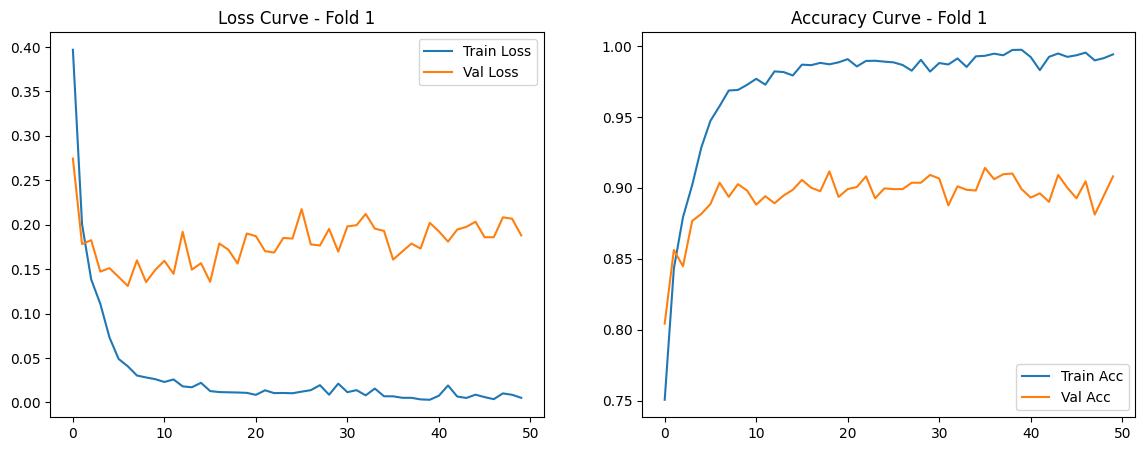

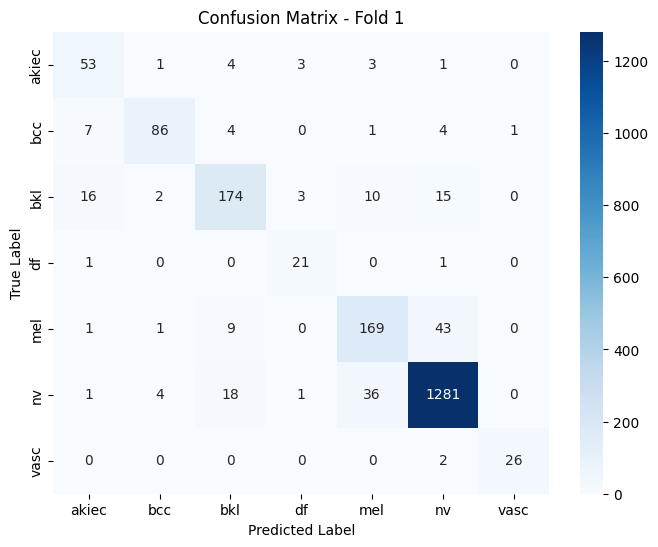

Semua log dan grafik untuk Fold 1 berhasil disimpan di folder: results_exp2

---> Memulai Fold 2 <---
Epoch 1/50 - Train Loss: 0.4060 Acc: 0.7493 | Val Loss: 0.2689 Acc: 0.8118
Epoch 2/50 - Train Loss: 0.2098 Acc: 0.8354 | Val Loss: 0.1795 Acc: 0.8622
Epoch 3/50 - Train Loss: 0.1514 Acc: 0.8701 | Val Loss: 0.1728 Acc: 0.8692
Epoch 4/50 - Train Loss: 0.1138 Acc: 0.8970 | Val Loss: 0.1568 Acc: 0.8687
Epoch 5/50 - Train Loss: 0.0839 Acc: 0.9196 | Val Loss: 0.1385 Acc: 0.8867
Epoch 6/50 - Train Loss: 0.0599 Acc: 0.9361 | Val Loss: 0.1690 Acc: 0.8802
Epoch 7/50 - Train Loss: 0.0545 Acc: 0.9477 | Val Loss: 0.1510 Acc: 0.8897
Epoch 8/50 - Train Loss: 0.0381 Acc: 0.9586 | Val Loss: 0.1423 Acc: 0.9006
Epoch 9/50 - Train Loss: 0.0294 Acc: 0.9675 | Val Loss: 0.1526 Acc: 0.8997
Epoch 10/50 - Train Loss: 0.0361 Acc: 0.9614 | Val Loss: 0.1435 Acc: 0.9016
Epoch 11/50 - Train Loss: 0.0204 Acc: 0.9769 | Val Loss: 0.1331 Acc: 0.9106
Epoch 12/50 - Train Loss: 0.0247 Acc: 0.9727 | Val Loss: 0.1420 Acc: 0.

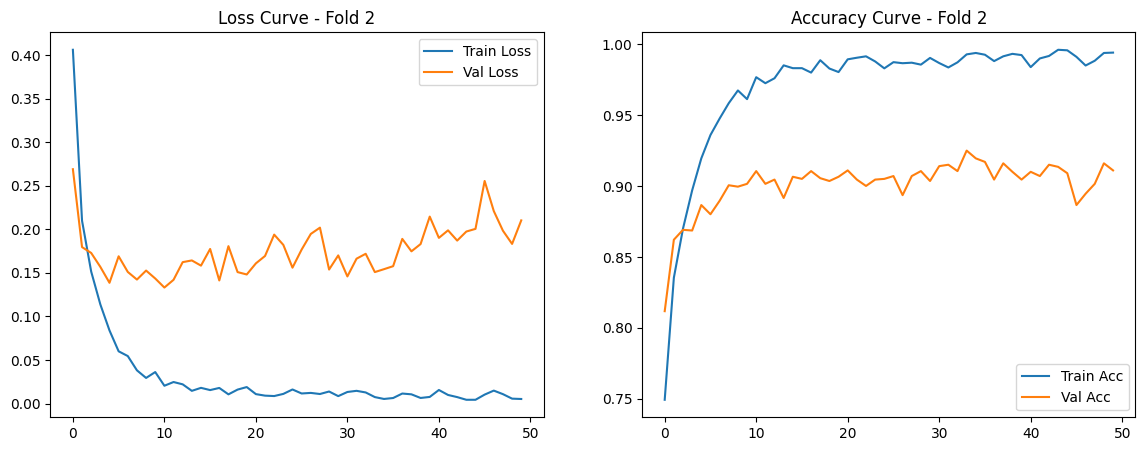

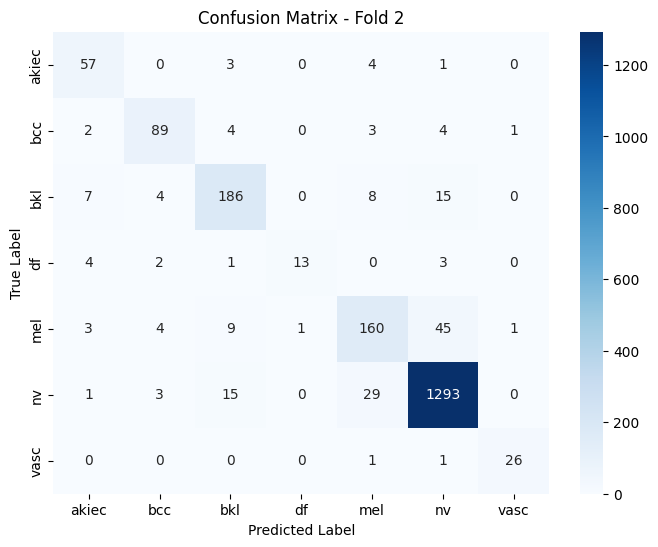

Semua log dan grafik untuk Fold 2 berhasil disimpan di folder: results_exp2

---> Memulai Fold 3 <---
Epoch 1/50 - Train Loss: 0.3957 Acc: 0.7531 | Val Loss: 0.2734 Acc: 0.8013
Epoch 2/50 - Train Loss: 0.2075 Acc: 0.8355 | Val Loss: 0.2258 Acc: 0.8357
Epoch 3/50 - Train Loss: 0.1430 Acc: 0.8799 | Val Loss: 0.1868 Acc: 0.8502
Epoch 4/50 - Train Loss: 0.0997 Acc: 0.9060 | Val Loss: 0.1664 Acc: 0.8657
Epoch 5/50 - Train Loss: 0.0735 Acc: 0.9277 | Val Loss: 0.1626 Acc: 0.8737
Epoch 6/50 - Train Loss: 0.0582 Acc: 0.9405 | Val Loss: 0.1510 Acc: 0.8897
Epoch 7/50 - Train Loss: 0.0438 Acc: 0.9534 | Val Loss: 0.1632 Acc: 0.8822
Epoch 8/50 - Train Loss: 0.0415 Acc: 0.9567 | Val Loss: 0.1789 Acc: 0.8847
Epoch 9/50 - Train Loss: 0.0295 Acc: 0.9662 | Val Loss: 0.1554 Acc: 0.8952
Epoch 10/50 - Train Loss: 0.0218 Acc: 0.9754 | Val Loss: 0.1627 Acc: 0.8892
Epoch 11/50 - Train Loss: 0.0218 Acc: 0.9758 | Val Loss: 0.1816 Acc: 0.8867
Epoch 12/50 - Train Loss: 0.0185 Acc: 0.9809 | Val Loss: 0.1812 Acc: 0.

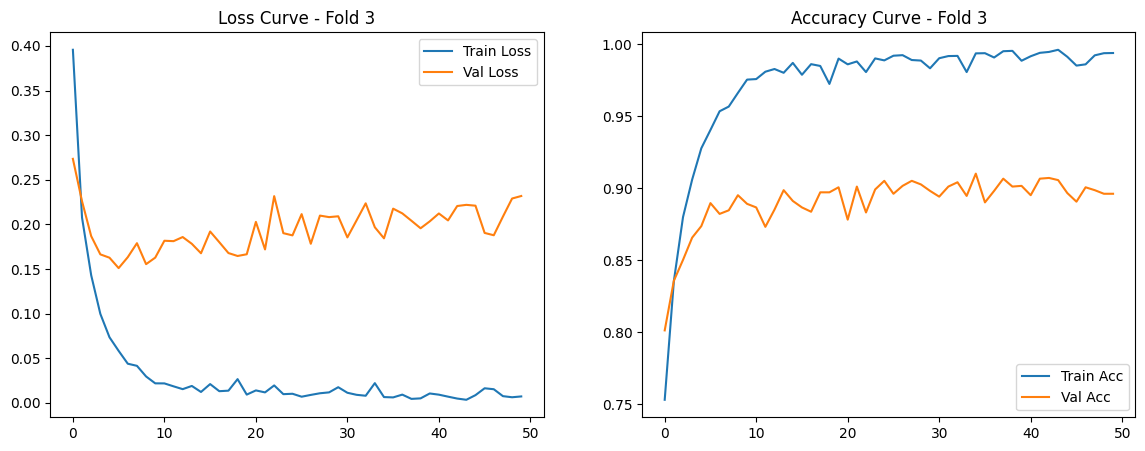

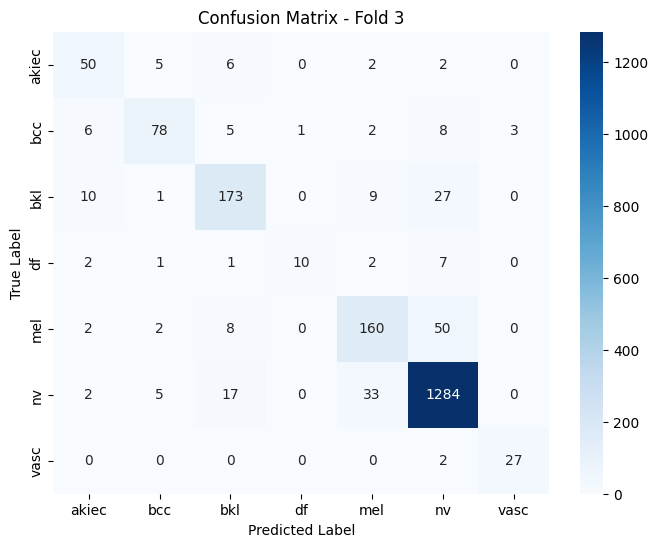

Semua log dan grafik untuk Fold 3 berhasil disimpan di folder: results_exp2

---> Memulai Fold 4 <---
Epoch 1/50 - Train Loss: 0.4069 Acc: 0.7478 | Val Loss: 0.2787 Acc: 0.8048
Epoch 2/50 - Train Loss: 0.2138 Acc: 0.8347 | Val Loss: 0.2049 Acc: 0.8452
Epoch 3/50 - Train Loss: 0.1496 Acc: 0.8743 | Val Loss: 0.2002 Acc: 0.8412
Epoch 4/50 - Train Loss: 0.1055 Acc: 0.9046 | Val Loss: 0.1811 Acc: 0.8557
Epoch 5/50 - Train Loss: 0.0775 Acc: 0.9214 | Val Loss: 0.1460 Acc: 0.8942
Epoch 6/50 - Train Loss: 0.0649 Acc: 0.9340 | Val Loss: 0.1389 Acc: 0.8827
Epoch 7/50 - Train Loss: 0.0435 Acc: 0.9527 | Val Loss: 0.1515 Acc: 0.8942
Epoch 8/50 - Train Loss: 0.0373 Acc: 0.9598 | Val Loss: 0.1670 Acc: 0.8827
Epoch 9/50 - Train Loss: 0.0380 Acc: 0.9631 | Val Loss: 0.1670 Acc: 0.8972
Epoch 10/50 - Train Loss: 0.0234 Acc: 0.9768 | Val Loss: 0.1581 Acc: 0.9026
Epoch 11/50 - Train Loss: 0.0202 Acc: 0.9804 | Val Loss: 0.1361 Acc: 0.9056
Epoch 12/50 - Train Loss: 0.0207 Acc: 0.9764 | Val Loss: 0.1471 Acc: 0.

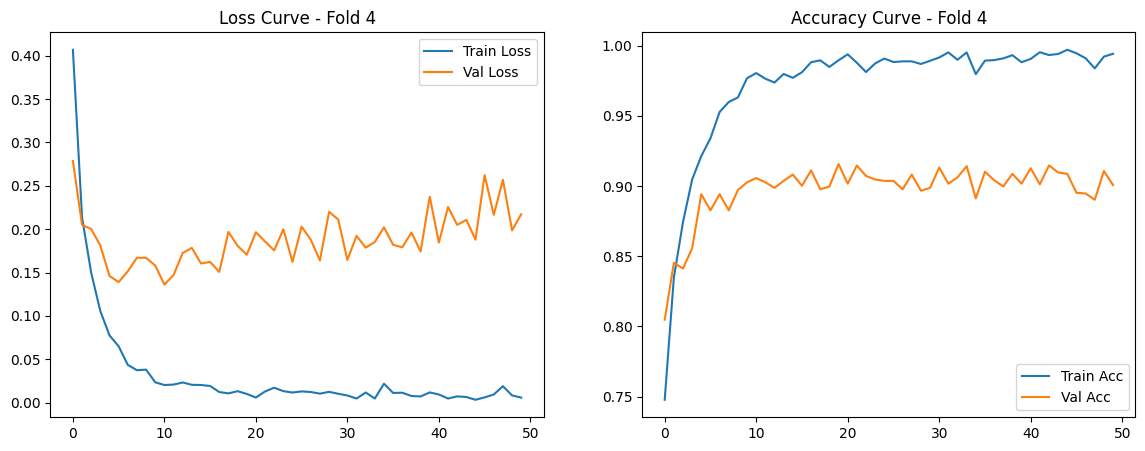

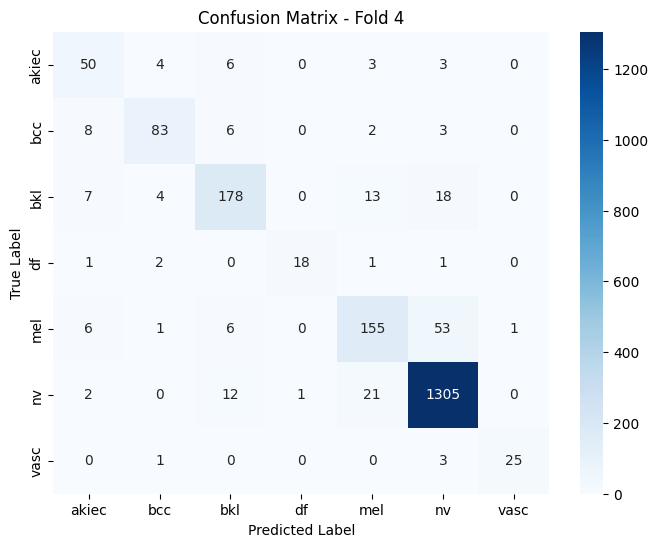

Semua log dan grafik untuk Fold 4 berhasil disimpan di folder: results_exp2

---> Memulai Fold 5 <---
Epoch 1/50 - Train Loss: 0.4007 Acc: 0.7491 | Val Loss: 0.2762 Acc: 0.8033
Epoch 2/50 - Train Loss: 0.2169 Acc: 0.8389 | Val Loss: 0.1941 Acc: 0.8462
Epoch 3/50 - Train Loss: 0.1406 Acc: 0.8794 | Val Loss: 0.1897 Acc: 0.8542
Epoch 4/50 - Train Loss: 0.1022 Acc: 0.9091 | Val Loss: 0.1581 Acc: 0.8662
Epoch 5/50 - Train Loss: 0.0746 Acc: 0.9295 | Val Loss: 0.1477 Acc: 0.8792
Epoch 6/50 - Train Loss: 0.0555 Acc: 0.9455 | Val Loss: 0.1522 Acc: 0.8827
Epoch 7/50 - Train Loss: 0.0481 Acc: 0.9517 | Val Loss: 0.1703 Acc: 0.8757
Epoch 8/50 - Train Loss: 0.0297 Acc: 0.9700 | Val Loss: 0.1598 Acc: 0.8927
Epoch 9/50 - Train Loss: 0.0273 Acc: 0.9718 | Val Loss: 0.1444 Acc: 0.9011
Epoch 10/50 - Train Loss: 0.0219 Acc: 0.9769 | Val Loss: 0.1633 Acc: 0.8947
Epoch 11/50 - Train Loss: 0.0241 Acc: 0.9734 | Val Loss: 0.1778 Acc: 0.8847
Epoch 12/50 - Train Loss: 0.0185 Acc: 0.9794 | Val Loss: 0.1755 Acc: 0.

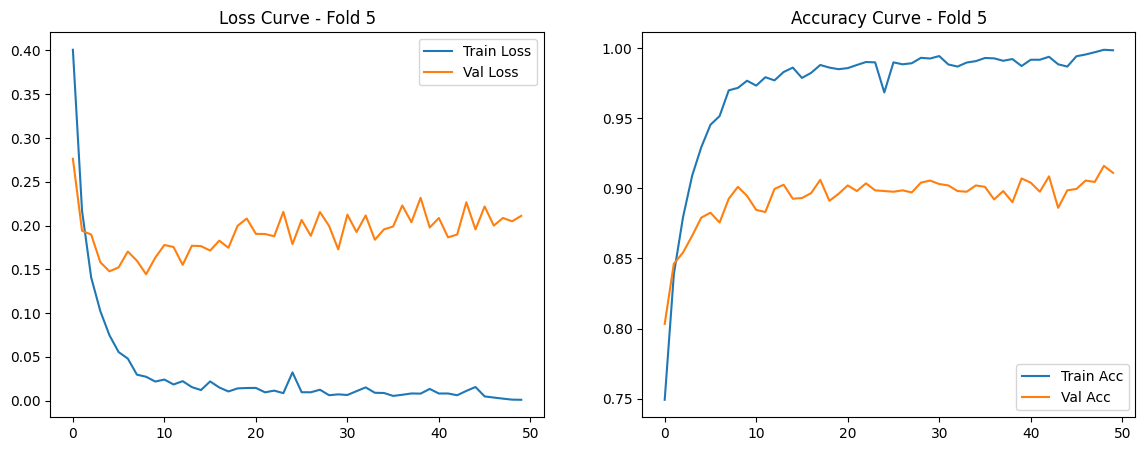

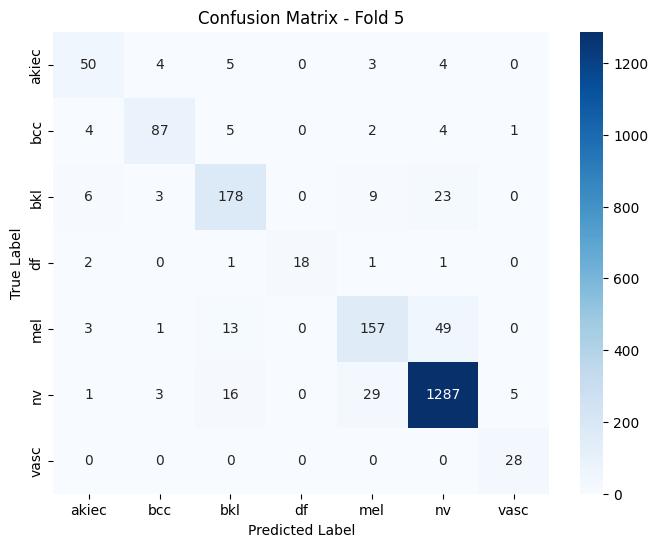

Semua log dan grafik untuk Fold 5 berhasil disimpan di folder: results_exp2

ALHAMDULILLAH, EKSPERIMEN 2 SELESAI TOTAL!
Semua grafik, metric, dan file .pth telah diamankan.


In [7]:
# CELL 7: MASTER EXECUTION LOOP (RUN EXPERIMENT 1)
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

print(f"Mulai Eksperimen 2: ConvNeXt + Spatial Attention + Focal Loss")
print(f"Menyimpan di folder: {SAVE_DIR}\n" + "="*50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n---> Memulai Fold {fold} <---")
    
    # Bagi dataframe berdasarkan index fold
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    # Buat Dataset dan DataLoader
    train_dataset = HAM10000Dataset(train_df, transform=train_transform)
    val_dataset = HAM10000Dataset(val_df, transform=val_transform)
    
    # Gunakan num_workers=4 atau 8 jika CPU Xeon Anda mendukung untuk mempercepat I/O
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Inisialisasi Ulang Model dan Optimizer untuk setiap Fold
    model = ConvNeXt_Spatial_Attention(num_classes=7).to(device)
    criterion = FocalLoss(gamma=2) # Mengatasi Imbalance
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Mulai Training
    history, t_time, max_mem = train_model(
        fold=fold, 
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=NUM_EPOCHS
    )
    
    # Mulai Evaluasi & Plotting
    evaluate_and_plot(
        fold=fold, 
        model=model, 
        val_loader=val_loader, 
        history=history, 
        training_time=t_time, 
        max_memory=max_mem, 
        class_names=class_names
    )
    
print("\n" + "="*50)
print("ALHAMDULILLAH, EKSPERIMEN 2 SELESAI TOTAL!")
print("Semua grafik, metric, dan file .pth telah diamankan.")

In [9]:
# CELL 8: SUMMARY CALCULATOR (MEAN & STD) - FIXED VERSION
import os
import pandas as pd
import glob

# Pastikan path folder benar sesuai hasil running tadi
results_path = "results_exp2"
csv_files = glob.glob(os.path.join(results_path, "exp2_fold*_classification_report.csv"))

if len(csv_files) < 5:
    print(f"Peringatan: Baru ditemukan {len(csv_files)} file CSV. Pastikan 5 fold sudah selesai running semua.")
else:
    all_reports = []
    
    for file in csv_files:
        # Perbaikan: index_col=0 digunakan agar kolom pertama (nama kelas) jadi index
        df_fold = pd.read_csv(file, index_col=0) 
        all_reports.append(df_fold)
    
    # Gabungkan semua fold
    full_concat = pd.concat(all_reports)
    
    # Hitung rata-rata (Mean) dan Standar Deviasi (Std)
    mean_report = full_concat.groupby(full_concat.index).mean()
    std_report = full_concat.groupby(full_concat.index).std()

    # Mengambil metrik utama (Accuracy dan Macro F1)
    # Note: Di report sklearn, accuracy biasanya ada di baris 'accuracy' kolom 'precision'
    mean_accuracy = mean_report.loc['accuracy', 'precision']
    mean_macro_f1 = mean_report.loc['macro avg', 'f1-score']
    
    std_accuracy = std_report.loc['accuracy', 'precision']
    std_macro_f1 = std_report.loc['macro avg', 'f1-score']
    
    print("="*50)
    print("   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)")
    print("="*50)
    print(f"Mean Accuracy : {mean_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"Mean Macro F1 : {mean_macro_f1:.4f} ± {std_macro_f1:.4f}")
    print("-" * 50)
    
    # Tampilkan tabel lengkap rata-rata per kelas agar bisa langsung di-copy ke Paper
    print("\nLaporan Lengkap (Mean Performance per Class):")
    target_rows = class_names + ['macro avg', 'weighted avg']
    summary_table = mean_report.loc[target_rows, ['precision', 'recall', 'f1-score']]
    
    # Menampilkan tabel
    from IPython.display import display
    display(summary_table)
    
    # Simpan hasil akhir ke CSV untuk arsip
    summary_table.to_csv(os.path.join(results_path, "EXP2_FINAL_SUMMARY_STATISTICS.csv"))
    print(f"\n[INFO] Laporan final telah disimpan di: {results_path}/EXP2_FINAL_SUMMARY_STATISTICS.csv")

   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)
Mean Accuracy : 0.9021 ± 0.0078
Mean Macro F1 : 0.8306 ± 0.0233
--------------------------------------------------

Laporan Lengkap (Mean Performance per Class):


,precision,recall,f1-score
akiec,0.713770,0.795338,0.751609
bcc,0.879342,0.822939,0.849940
bkl,0.836368,0.808921,0.822315
df,0.907006,0.695652,0.769932
mel,0.779475,0.719658,0.748105
nv,0.942625,0.961969,0.952174
vasc,0.915320,0.930049,0.920319
macro avg,0.853415,0.819218,0.830628
weighted avg,0.901323,0.902147,0.900903



[INFO] Laporan final telah disimpan di: results_exp2/EXP2_FINAL_SUMMARY_STATISTICS.csv
